# Démo floutage des plaques — avant / après (Phase 4)

Démonstration visuelle de la chaîne de floutage (`dl/src/flouter.py`) aux réglages par
défaut consignés dans l'**ADR DL 0004** : seuil de score 0,3, marge 15 %, rayon de flou
proportionnel à la hauteur de boîte (plancher 6 px).

**Source des images : UC3M-LP** (Universidad Carlos III de Madrid, split *test*, licence
**CC BY 4.0** — publiables dans le dossier de certification avec attribution). Deux raisons
de ne pas utiliser le lot de mesure réel (87 photos personnelles, fiche DL 0002) : ce sont
des données personnelles, et la règle du pilier est que **seules les images floutées
sortent du poste** — une grille « avant » à plaques lisibles ne serait pas publiable.

**Ce que cette démo n'est pas** : une mesure. Le domaine UC3M-LP n'a jamais été évalué
(arc clos sans verdict, fiche DL 0003). Les chiffres qui engagent le pilier sont ceux de
la fiche DL 0002 (rappel réel 0,895, couverture après marge 95,3 %).

In [1]:
from pathlib import Path
import shutil, sys

sys.path.insert(0, str(Path("../../src").resolve()))
from flouter import flouter_dossier

TEST = Path("../../data/uc3m-lp/raw/UC3M-LP/test")
ENTREE = Path("../../data/uc3m-lp/demo_in")   # copies de travail — data/ est gitignoré
SORTIE = Path("../../data/uc3m-lp/demo_out")  # jamais dans raw/ (garde-fou de flouter_dossier)

N = 12
ENTREE.mkdir(parents=True, exist_ok=True)
for p in sorted(TEST.glob("*.jpg"))[:N]:
    shutil.copy(p, ENTREE / p.name)

bilan = flouter_dossier(ENTREE, SORTIE)
bilan

12 images -> ../../data/uc3m-lp/demo_out : 12 plaques floutées sur 11 images (1 sans détection)


{'images': 12, 'avec_plaque': 11, 'boites': 12}

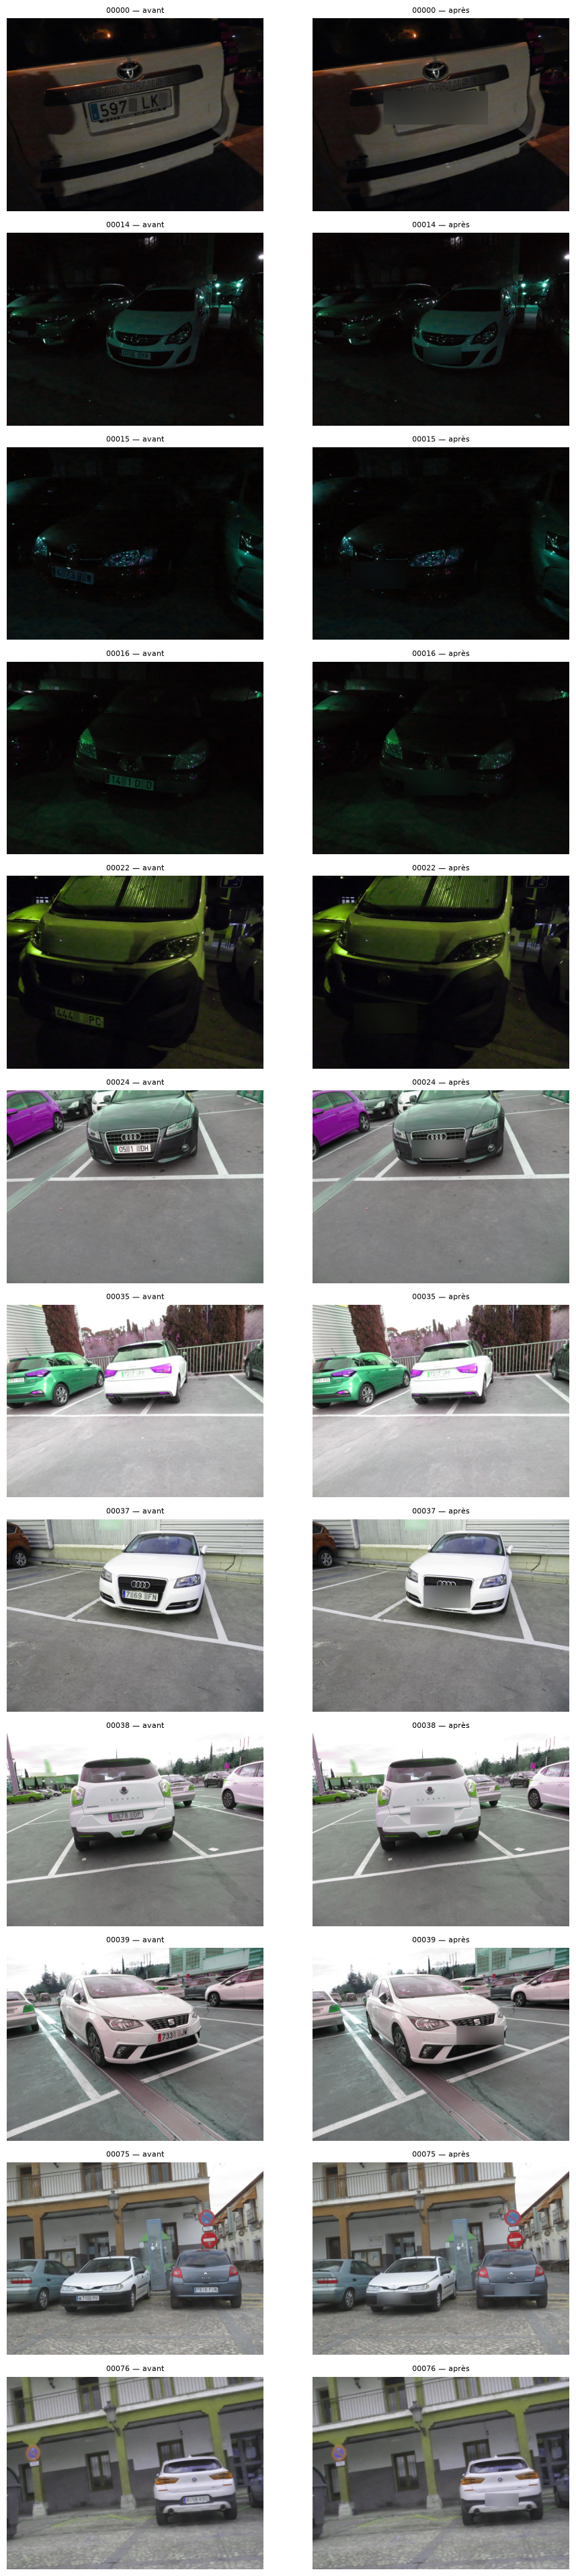

In [2]:
import matplotlib.pyplot as plt
from PIL import Image

paires = sorted(ENTREE.iterdir())
fig, axes = plt.subplots(len(paires), 2, figsize=(10, 3.2 * len(paires)))
for ax_avant, ax_apres, chemin in zip(axes[:, 0], axes[:, 1], paires):
    for ax, dossier, titre in ((ax_avant, ENTREE, "avant"), (ax_apres, SORTIE, "après")):
        img = Image.open(dossier / chemin.name)
        img.thumbnail((640, 640))  # affichage seulement — le floutage a eu lieu pleine résolution
        ax.imshow(img); ax.set_title(f"{chemin.stem} — {titre}", fontsize=8); ax.axis("off")
fig.tight_layout()
plt.show()

## Lecture

- Sur ces 12 images, 11 plaques sont détectées et floutées ; 1 image reste sans détection —
  cohérent avec la limite affichée partout : **le floutage n'est pas garanti à 100 %**
  (fiche DL 0002 : 4 plaques sur 95 sans aucun flou sur le domaine réel).
- Le rayon proportionnel se voit : les plaques en gros plan reçoivent un flou massif, les
  plaques lointaines un flou léger mais suffisant à l'illisibilité.
- Réglages, garde-fous (jamais d'écriture dans `raw/`) et couverture mesurée : **ADR DL 0004**.

*Images : dataset UC3M-LP, Universidad Carlos III de Madrid, licence CC BY 4.0.*